# TransferBench

# Experiment 4

## EfficientNet-B0 Fine-Tuning

This notebook performs partial fine-tuning on EfficientNet-B0.

The classifier and the last feature block are trainable while the remaining backbone stays frozen.

Outputs

- Fine-Tuned Model
- Metrics
- Learning Curves
- Confusion Matrix

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from utils.dataset import load_dataset
from utils.models import build_model

from utils.training import (
    train_model,
    print_summary,
)

from utils.evaluation import (
    calculate_metrics,
    print_metrics,
    export_metrics_csv,
    build_confusion_matrix,
)

from utils.visualization import (
    plot_loss_curve,
    plot_accuracy_curve,
    plot_confusion_matrix,
)

from utils.paths import *

Import OK ✅


In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Load Dataset

In [4]:
train_loader, test_loader, class_names = load_dataset(
    dataset_name="cifar10",
    batch_size=32,
    image_size=224,
)

C:\Users\pc1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Build EfficientNet-B0

In [5]:
model = build_model(
    model_name="efficientnet",
    num_classes=10,
    strategy="finetune",
)

model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

## Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),
    lr=1e-4,
)

In [7]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [8]:
EPOCHS = 20

checkpoint_path = get_model_path(
    "best_efficientnet_finetune"
)

print(checkpoint_path)

C:\Users\pc1\TransferBench\models\best_efficientnet_finetune.pth


## Train Model

In [9]:
results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=checkpoint_path,
)

Training Started
Epoch 01/20 | Train Loss: 1.0736 | Train Acc: 0.6870 | Val Loss: 0.5652 | Val Acc: 0.8180
Epoch 02/20 | Train Loss: 0.6686 | Train Acc: 0.7765 | Val Loss: 0.4772 | Val Acc: 0.8419
Epoch 03/20 | Train Loss: 0.6029 | Train Acc: 0.7954 | Val Loss: 0.4497 | Val Acc: 0.8475
Epoch 04/20 | Train Loss: 0.5635 | Train Acc: 0.8066 | Val Loss: 0.4230 | Val Acc: 0.8574
Epoch 05/20 | Train Loss: 0.5404 | Train Acc: 0.8168 | Val Loss: 0.4149 | Val Acc: 0.8606
Epoch 06/20 | Train Loss: 0.5168 | Train Acc: 0.8220 | Val Loss: 0.3816 | Val Acc: 0.8706
Epoch 07/20 | Train Loss: 0.5011 | Train Acc: 0.8295 | Val Loss: 0.3805 | Val Acc: 0.8704
Epoch 08/20 | Train Loss: 0.4835 | Train Acc: 0.8335 | Val Loss: 0.3773 | Val Acc: 0.8716
Epoch 09/20 | Train Loss: 0.4631 | Train Acc: 0.8430 | Val Loss: 0.3619 | Val Acc: 0.8755
Epoch 10/20 | Train Loss: 0.4556 | Train Acc: 0.8446 | Val Loss: 0.3459 | Val Acc: 0.8820
Epoch 11/20 | Train Loss: 0.4454 | Train Acc: 0.8482 | Val Loss: 0.3365 | Val Acc: 

## Evaluation

In [10]:
metrics = calculate_metrics(
    results["targets"],
    results["predictions"],
)

print_metrics(metrics)

Evaluation Results
Accuracy  : 0.8905
Precision : 0.8918
Recall    : 0.8905
F1 Score  : 0.8900


In [11]:
metrics_df = export_metrics_csv(
    metrics=metrics,
    model_name="EfficientNet-B0",
    strategy="Fine-Tuning",
    training_time=results["training_time"],
    save_path=get_metrics_path(
        "efficientnet_finetune"
    ),
)

metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,EfficientNet-B0,Fine-Tuning,0.8905,0.891752,0.8905,0.890035,1525.123615


## Learning Curves

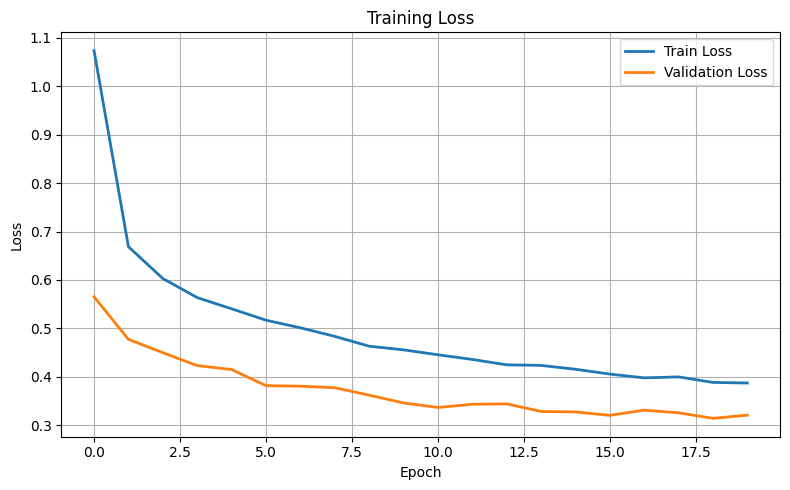

In [12]:
plot_loss_curve(
    history=results["history"],
    save_path=get_loss_plot_path(
        "efficientnet_finetune"
    ),
)

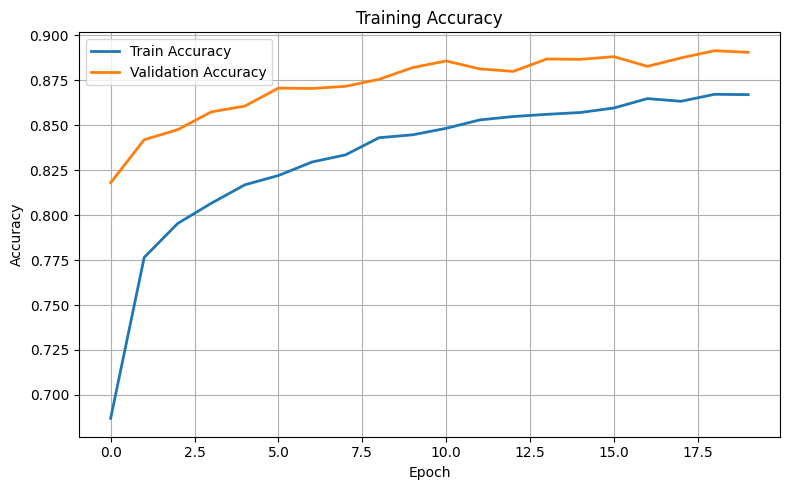

In [13]:
plot_accuracy_curve(
    history=results["history"],
    save_path=get_accuracy_plot_path(
        "efficientnet_finetune"
    ),
)

## Confusion Matrix

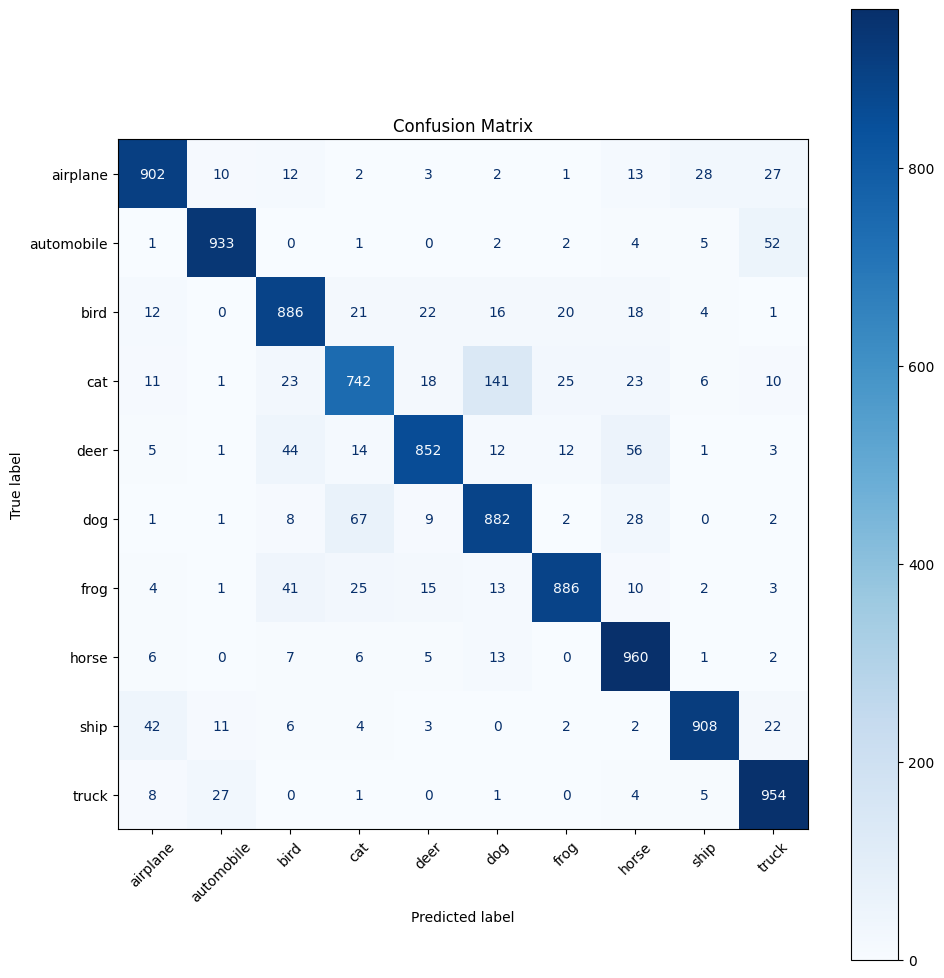

In [14]:
cm = build_confusion_matrix(
    results["targets"],
    results["predictions"],
)

plot_confusion_matrix(
    matrix=cm,
    class_names=class_names,
    save_path=get_confusion_matrix_path(
        "efficientnet_finetune"
    ),
)

## Training Summary

In [16]:
print_summary(results)



Training Summary
Best Accuracy : 0.8914
Training Time : 1525.12 sec
Checkpoint    : C:\Users\pc1\TransferBench\models\best_efficientnet_finetune.pth


In [17]:
metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,EfficientNet-B0,Fine-Tuning,0.8905,0.891752,0.8905,0.890035,1525.123615


In [18]:
results["history"]

{'train_loss': [1.0736375213432312,
  0.6686379120445252,
  0.6029075402259827,
  0.5635305417919159,
  0.5403828499221802,
  0.5168159254646302,
  0.501148799753189,
  0.4834553365421295,
  0.4630924511766434,
  0.4555657075834274,
  0.44538537893772123,
  0.4357540545797348,
  0.4246480359172821,
  0.42341681290626526,
  0.41543185647964476,
  0.4054927596306801,
  0.3976830278110504,
  0.3996434024524689,
  0.3882558544206619,
  0.3869876257276535],
 'train_acc': [0.68698,
  0.77646,
  0.79538,
  0.80658,
  0.81684,
  0.822,
  0.8295,
  0.83348,
  0.84302,
  0.84464,
  0.84824,
  0.85292,
  0.8548,
  0.85602,
  0.85704,
  0.85956,
  0.86478,
  0.86328,
  0.86716,
  0.86698],
 'val_loss': [0.5652455513954162,
  0.4771931105136871,
  0.4497095970153809,
  0.42301376144886016,
  0.4148951059818268,
  0.3815803297042847,
  0.38047299354076386,
  0.37730871448516845,
  0.36191916579008104,
  0.3458631088495254,
  0.3365055282354355,
  0.34310099008083345,
  0.3439049730539322,
  0.328284

In [19]:
results

{'history': {'train_loss': [1.0736375213432312,
   0.6686379120445252,
   0.6029075402259827,
   0.5635305417919159,
   0.5403828499221802,
   0.5168159254646302,
   0.501148799753189,
   0.4834553365421295,
   0.4630924511766434,
   0.4555657075834274,
   0.44538537893772123,
   0.4357540545797348,
   0.4246480359172821,
   0.42341681290626526,
   0.41543185647964476,
   0.4054927596306801,
   0.3976830278110504,
   0.3996434024524689,
   0.3882558544206619,
   0.3869876257276535],
  'train_acc': [0.68698,
   0.77646,
   0.79538,
   0.80658,
   0.81684,
   0.822,
   0.8295,
   0.83348,
   0.84302,
   0.84464,
   0.84824,
   0.85292,
   0.8548,
   0.85602,
   0.85704,
   0.85956,
   0.86478,
   0.86328,
   0.86716,
   0.86698],
  'val_loss': [0.5652455513954162,
   0.4771931105136871,
   0.4497095970153809,
   0.42301376144886016,
   0.4148951059818268,
   0.3815803297042847,
   0.38047299354076386,
   0.37730871448516845,
   0.36191916579008104,
   0.3458631088495254,
   0.33650552823

## Generated Files

In [20]:
print("=" * 60)

print("Saved Model")
print(get_model_path("best_efficientnet_finetune"))

print()

print("Metrics")
print(get_metrics_path("efficientnet_finetune"))

print()

print("Loss Curve")
print(get_loss_plot_path("efficientnet_finetune"))

print()

print("Accuracy Curve")
print(get_accuracy_plot_path("efficientnet_finetune"))

print()

print("Confusion Matrix")
print(get_confusion_matrix_path("efficientnet_finetune"))

print("=" * 60)

Saved Model
C:\Users\pc1\TransferBench\models\best_efficientnet_finetune.pth

Metrics
C:\Users\pc1\TransferBench\results\efficientnet_finetune_metrics.csv

Loss Curve
C:\Users\pc1\TransferBench\figures\efficientnet_finetune_loss.png

Accuracy Curve
C:\Users\pc1\TransferBench\figures\efficientnet_finetune_accuracy.png

Confusion Matrix
C:\Users\pc1\TransferBench\figures\confusion_matrix_efficientnet_finetune.png
